<a href="https://colab.research.google.com/github/Akira006/orion-fl-dr-research/blob/main/notebooks/Multiclient/exp2_fl_loss_asc_multiclient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Sat May  2 01:42:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   30C    P0             53W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
# =========================
# CELL 1A — MOUNT GOOGLE DRIVE
# =========================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# =========================
# CELL 1B — IMPORTS + CONFIG
# =========================
import os, json, random, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# ── Reproducibility ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================
# PATH CONFIG — PROJECT
# =========================
PROJECT_DIR = "/content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research"

DATASET_NAME    = "MultiClient"
EXPERIMENT_NAME = "exp2_fl_loss_asc"
MODEL_NAME      = "mobilenet"

BASE_RESULT_DIR = os.path.join(PROJECT_DIR, "results", DATASET_NAME, EXPERIMENT_NAME, MODEL_NAME)
MODELS_DIR      = os.path.join(BASE_RESULT_DIR, "models")
LOGS_DIR        = os.path.join(BASE_RESULT_DIR, "logs")
FIGURES_DIR     = os.path.join(BASE_RESULT_DIR, "figures")

os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(LOGS_DIR,    exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# =========================
# PATH CONFIG — CLIENTS
# =========================
# Client 0 — DDR
DDR_NPZ_PATH   = "/content/drive/MyDrive/S-Class/Orion/OrionFL/DDR_Dataset/DDR_dataset_224.npz"
DDR_LABEL_PATH = "/content/drive/MyDrive/S-Class/Orion/OrionFL/DDR_Dataset/DR_grading.csv"

# Client 1 — EyePACS
EYEPACS_NPZ_PATH   = "/content/drive/MyDrive/S-Class/Orion/OrionFL/EyePACS_Dataset/training/EyePACS_dataset_224.npz"
EYEPACS_LABEL_PATH = "/content/drive/MyDrive/S-Class/Orion/OrionFL/EyePACS_Dataset/training/trainLabels.csv"

# Client 2 — APTOS  (label dari NPZ internal)
APTOS_NPZ_PATH = "/content/drive/MyDrive/S-Class/Orion/OrionFL/APTOS_2019/preprocessed/orion_dr_224.npz"

# =========================
# FL CONFIG
# =========================
IMG_SIZE             = (224, 224)
BATCH_SIZE           = 32
NUM_CLASSES          = 5
NUM_CLIENTS          = 3
CLIENT_NAMES         = ["DDR", "EyePACS", "APTOS"]

FL_ROUNDS            = 10
EPOCHS_LOCAL_STAGE1  = 3
EPOCHS_LOCAL_STAGE2  = 3

LEARNING_RATE_STAGE1   = 1e-3
LEARNING_RATE_STAGE2   = 1e-6
UNFREEZE_LAST_N_LAYERS = 10

SORT_STRATEGY = "loss_ascending"

# =========================
# DEBUG INFO
# =========================
print("TensorFlow version:", tf.__version__)
print("SORT_STRATEGY      :", SORT_STRATEGY)
print()
print("PROJECT_DIR exists     :", os.path.exists(PROJECT_DIR))
print("DDR_NPZ exists         :", os.path.exists(DDR_NPZ_PATH))
print("DDR_LABEL exists       :", os.path.exists(DDR_LABEL_PATH))
print("EYEPACS_NPZ exists     :", os.path.exists(EYEPACS_NPZ_PATH))
print("EYEPACS_LABEL exists   :", os.path.exists(EYEPACS_LABEL_PATH))
print("APTOS_NPZ exists       :", os.path.exists(APTOS_NPZ_PATH))
print()
print("numpy  :", np.__version__)
print("pandas :", pd.__version__)
print("tf     :", tf.__version__)
print("\nAll imports OK.")

TensorFlow version: 2.20.0
SORT_STRATEGY      : loss_ascending

PROJECT_DIR exists     : True
DDR_NPZ exists         : True
DDR_LABEL exists       : True
EYEPACS_NPZ exists     : True
EYEPACS_LABEL exists   : True
APTOS_NPZ exists       : True

numpy  : 2.0.2
pandas : 2.2.2
tf     : 2.20.0

All imports OK.


In [4]:
# =========================
# CELL 2 — LOAD CLIENT 0: DDR
# =========================
ddr_data = np.load(DDR_NPZ_PATH, allow_pickle=True)
print("DDR NPZ keys:", ddr_data.files)
X_ddr = ddr_data["X"]

assert os.path.exists(DDR_LABEL_PATH), f"Label CSV tidak ditemukan: {DDR_LABEL_PATH}"
ddr_label_df = pd.read_csv(DDR_LABEL_PATH)
y_ddr        = ddr_label_df["diagnosis"].values.astype(np.int64)

assert len(X_ddr) == len(y_ddr), (
    f"DDR: jumlah images ({len(X_ddr)}) != jumlah label ({len(y_ddr)})."
)

print("DDR — X shape:", X_ddr.shape, "| y shape:", y_ddr.shape)
print("Label distribution:")
print(pd.Series(y_ddr).value_counts().sort_index())
print()

DDR NPZ keys: ['X', 'y', 'filenames']
DDR — X shape: (12522, 224, 224, 3) | y shape: (12522,)
Label distribution:
0    6266
1     630
2    4477
3     236
4     913
Name: count, dtype: int64



In [5]:
# =========================
# CELL 3 — LOAD CLIENT 1: EyePACS
# =========================
eyepacs_data = np.load(EYEPACS_NPZ_PATH, allow_pickle=True)
X_eyepacs    = eyepacs_data["images"]

assert os.path.exists(EYEPACS_LABEL_PATH), f"Label CSV tidak ditemukan: {EYEPACS_LABEL_PATH}"
eyepacs_label_df = pd.read_csv(EYEPACS_LABEL_PATH)
y_eyepacs        = eyepacs_label_df["level"].values.astype(np.int64)

assert len(X_eyepacs) == len(y_eyepacs), (
    f"EyePACS: jumlah images ({len(X_eyepacs)}) != jumlah label ({len(y_eyepacs)})."
)

print("EyePACS — X shape:", X_eyepacs.shape, "| y shape:", y_eyepacs.shape)
print("Label distribution:")
print(pd.Series(y_eyepacs).value_counts().sort_index())
print()

EyePACS — X shape: (35126, 224, 224, 3) | y shape: (35126,)
Label distribution:
0    25810
1     2443
2     5292
3      873
4      708
Name: count, dtype: int64



In [6]:
# =========================
# CELL 4 — LOAD CLIENT 2: APTOS
# =========================
aptos_data = np.load(APTOS_NPZ_PATH, allow_pickle=True)
X_aptos    = aptos_data["images"]
y_aptos    = aptos_data["labels"].astype(np.int64)

assert len(X_aptos) == len(y_aptos), (
    f"APTOS: jumlah images ({len(X_aptos)}) != jumlah label ({len(y_aptos)})."
)

print("APTOS — X shape:", X_aptos.shape, "| y shape:", y_aptos.shape)
print("Label distribution:")
print(pd.Series(y_aptos).value_counts().sort_index())
print()

APTOS — X shape: (3662, 224, 224, 3) | y shape: (3662,)
Label distribution:
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64



In [7]:
# =========================
# CELL 5 — PER-CLIENT TRAIN/VAL/TEST SPLIT (70:15:15 per dataset)
# =========================
def split_client(X, y, seed=SEED):
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        X, y, test_size=0.30, random_state=seed, stratify=y
    )
    X_v, X_te, y_v, y_te = train_test_split(
        X_tmp, y_tmp, test_size=0.50, random_state=seed, stratify=y_tmp
    )
    return X_tr, X_v, X_te, y_tr, y_v, y_te

X_tr_ddr,  X_v_ddr,  X_te_ddr,  y_tr_ddr,  y_v_ddr,  y_te_ddr  = split_client(X_ddr,     y_ddr)
X_tr_eye,  X_v_eye,  X_te_eye,  y_tr_eye,  y_v_eye,  y_te_eye  = split_client(X_eyepacs, y_eyepacs)
X_tr_apt,  X_v_apt,  X_te_apt,  y_tr_apt,  y_v_apt,  y_te_apt  = split_client(X_aptos,   y_aptos)

print("Split results:")
print(f"  DDR     — train: {len(y_tr_ddr):>6,} | val: {len(y_v_ddr):>5,} | test: {len(y_te_ddr):>5,}")
print(f"  EyePACS — train: {len(y_tr_eye):>6,} | val: {len(y_v_eye):>5,} | test: {len(y_te_eye):>5,}")
print(f"  APTOS   — train: {len(y_tr_apt):>6,} | val: {len(y_v_apt):>5,} | test: {len(y_te_apt):>5,}")
print()

# Global val & test = gabungan semua client (untuk global eval)
X_val_global  = np.concatenate([X_v_ddr,  X_v_eye,  X_v_apt],  axis=0)
y_val_global  = np.concatenate([y_v_ddr,  y_v_eye,  y_v_apt],  axis=0)
X_test_global = np.concatenate([X_te_ddr, X_te_eye, X_te_apt], axis=0)
y_test_global = np.concatenate([y_te_ddr, y_te_eye, y_te_apt], axis=0)

# Source tag untuk per-client analysis di test set
src_test_global = (
    ["DDR"]     * len(y_te_ddr) +
    ["EyePACS"] * len(y_te_eye) +
    ["APTOS"]   * len(y_te_apt)
)
src_test_global = np.array(src_test_global)

print(f"Global val  size : {len(y_val_global):,}")
print(f"Global test size : {len(y_test_global):,}")
print("\nGlobal test source breakdown:")
print(pd.Series(src_test_global).value_counts())

Split results:
  DDR     — train:  8,765 | val: 1,878 | test: 1,879
  EyePACS — train: 24,588 | val: 5,269 | test: 5,269
  APTOS   — train:  2,563 | val:   549 | test:   550

Global val  size : 7,696
Global test size : 7,698

Global test source breakdown:
EyePACS    5269
DDR        1879
APTOS       550
Name: count, dtype: int64


In [8]:
# =========================
# CELL 6 — PREPROCESS DATA (MobileNetV2 preprocess_input)
# =========================
def preproc(X):
    return preprocess_input(X.astype("float32"))

X_tr_ddr  = preproc(X_tr_ddr);   X_v_ddr  = preproc(X_v_ddr);   X_te_ddr  = preproc(X_te_ddr)
X_tr_eye  = preproc(X_tr_eye);   X_v_eye  = preproc(X_v_eye);   X_te_eye  = preproc(X_te_eye)
X_tr_apt  = preproc(X_tr_apt);   X_v_apt  = preproc(X_v_apt);   X_te_apt  = preproc(X_te_apt)

X_val_global  = preproc(X_val_global)
X_test_global = preproc(X_test_global)

print("Preprocessing done.")
print(f"  DDR train dtype  : {X_tr_ddr.dtype}")
print(f"  EyePACS train    : {X_tr_eye.dtype}")
print(f"  APTOS train      : {X_tr_apt.dtype}")

Preprocessing done.
  DDR train dtype  : float32
  EyePACS train    : float32
  APTOS train      : float32


In [9]:
# =========================
# CELL 7 — BUILD CLIENT DATA STRUCTURE
# =========================
# client_data[i] = (X_train, y_train) untuk client ke-i
# Order: 0=DDR, 1=EyePACS, 2=APTOS  (sesuai diagram)
client_data = [
    (X_tr_ddr, y_tr_ddr),    # Client 0 — DDR
    (X_tr_eye, y_tr_eye),    # Client 1 — EyePACS
    (X_tr_apt, y_tr_apt),    # Client 2 — APTOS
]

# Per-client val set (untuk per-client monitoring opsional)
client_val_data = [
    (X_v_ddr, y_v_ddr),
    (X_v_eye, y_v_eye),
    (X_v_apt, y_v_apt),
]

# Per-client test set (untuk per-client final eval)
client_test_data = [
    (X_te_ddr,  y_te_ddr),
    (X_te_eye,  y_te_eye),
    (X_te_apt,  y_te_apt),
]

print("Client data summary:")
for i, (cx, cy) in enumerate(client_data):
    dist = dict(zip(*np.unique(cy, return_counts=True)))
    print(f"  Client {i} ({CLIENT_NAMES[i]:<8}) | train: {len(cy):>6,} | dist: {dist}")

Client data summary:
  Client 0 (DDR     ) | train:  8,765 | dist: {np.int64(0): np.int64(4386), np.int64(1): np.int64(441), np.int64(2): np.int64(3134), np.int64(3): np.int64(165), np.int64(4): np.int64(639)}
  Client 1 (EyePACS ) | train: 24,588 | dist: {np.int64(0): np.int64(18067), np.int64(1): np.int64(1710), np.int64(2): np.int64(3704), np.int64(3): np.int64(611), np.int64(4): np.int64(496)}
  Client 2 (APTOS   ) | train:  2,563 | dist: {np.int64(0): np.int64(1263), np.int64(1): np.int64(259), np.int64(2): np.int64(699), np.int64(3): np.int64(135), np.int64(4): np.int64(207)}


In [10]:
# =========================
# CELL 8 — COMPUTE CLASS WEIGHTS PER CLIENT
# =========================
AUTOTUNE = tf.data.AUTOTUNE

def compute_client_class_weights(y, num_classes=NUM_CLASSES):
    classes  = np.unique(y)
    cw_array = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    cw = {int(c): float(w) for c, w in zip(classes, cw_array)}
    for c in range(num_classes):
        if c not in cw:
            cw[c] = 1.0
    return cw

client_class_weights = []
for i, (cx, cy) in enumerate(client_data):
    cw = compute_client_class_weights(cy)
    client_class_weights.append(cw)
    print(f"Client {i} ({CLIENT_NAMES[i]}) class weights: {cw}")

Client 0 (DDR) class weights: {0: 0.3996808025535796, 1: 3.9750566893424035, 2: 0.5593490746649649, 3: 10.624242424242425, 4: 2.7433489827856024}
Client 1 (EyePACS) class weights: {0: 0.2721868600210328, 1: 2.8757894736842107, 2: 1.327645788336933, 3: 8.048445171849426, 4: 9.914516129032258}
Client 2 (APTOS) class weights: {0: 0.4058590657165479, 1: 1.9791505791505792, 2: 0.7333333333333333, 3: 3.797037037037037, 4: 2.476328502415459}


In [11]:
# =========================
# CELL 9 — TF DATASET HELPERS
# =========================
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.05),
], name="light_augmentation")

def augment_fn(x, y):
    x = data_augmentation(x, training=True)
    return x, y

def make_client_dataset(X, y, augment=True):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    ds = ds.shuffle(buffer_size=len(X), seed=SEED)
    ds = ds.batch(BATCH_SIZE)
    if augment:
        ds = ds.map(augment_fn, num_parallel_calls=AUTOTUNE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

def make_eval_dataset(X, y):
    return (
        tf.data.Dataset.from_tensor_slices((X, y))
        .batch(BATCH_SIZE).prefetch(AUTOTUNE)
    )

# Global val & test ds
val_ds_global  = make_eval_dataset(X_val_global,  y_val_global)
test_ds_global = make_eval_dataset(X_test_global, y_test_global)

# Per-client val & test ds
client_val_ds  = [make_eval_dataset(x, y) for x, y in client_val_data]
client_test_ds = [make_eval_dataset(x, y) for x, y in client_test_data]

print("Global val_ds  ready  — batches:", len(val_ds_global))
print("Global test_ds ready  — batches:", len(test_ds_global))
print("Per-client val/test ds ready.")

Global val_ds  ready  — batches: 241
Global test_ds ready  — batches: 241
Per-client val/test ds ready.


In [12]:
# =========================
# CELL 10 — DEFINE MODEL BUILDER
# =========================
def build_mobilenetv2_model(input_shape=(224, 224, 3), num_classes=NUM_CLASSES):
    base_model = MobileNetV2(
        include_top=False, weights="imagenet", input_shape=input_shape
    )
    base_model.trainable = False

    inputs  = keras.Input(shape=input_shape)
    x       = base_model(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dropout(0.4)(x)
    outputs = layers.Dense(
        num_classes, activation="softmax",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)

    model = keras.Model(inputs, outputs)
    return model, base_model

In [13]:
# =========================
# CELL 11 — FEDAVG UTILITY
# =========================
def get_model_weights(model):    return model.get_weights()
def set_model_weights(model, w): model.set_weights(w)

def fedavg(global_weights, client_weights_list, client_sizes):
    """Weighted average bobot model berdasarkan ukuran dataset client."""
    total    = sum(client_sizes)
    averaged = []
    for layer_idx in range(len(global_weights)):
        layer_avg = np.sum(
            [client_weights_list[i][layer_idx] * client_sizes[i] / total
             for i in range(len(client_weights_list))],
            axis=0
        )
        averaged.append(layer_avg)
    return averaged

print("FedAvg utility ready.")

FedAvg utility ready.


In [14]:
# =========================
# CELL 12 — LOSS-BASED CLIENT SORTING UTILITY
# =========================
def evaluate_client_loss(model, X, y):
    """Hitung loss client menggunakan train data mereka sebagai proxy untuk sorting."""
    ds = tf.data.Dataset.from_tensor_slices((X, y)).batch(BATCH_SIZE).prefetch(AUTOTUNE)
    loss, _ = model.evaluate(ds, verbose=0)
    return loss

print("Loss-based sorting utility ready.")

Loss-based sorting utility ready.


In [15]:
# =========================
# CELL 13 — LOCAL TRAINING UTILITY
# =========================
def local_train(global_weights, client_X, client_y, client_cw, stage, epochs, lr):
    """
    Build model lokal, load global weights, train lokal, return updated weights.
    stage 1: frozen backbone | stage 2: partial unfreeze last N layers
    """
    local_model, local_base = build_mobilenetv2_model()
    local_model.set_weights(global_weights)

    if stage == 2:
        local_base.trainable = True
        for layer in local_base.layers[:-UNFREEZE_LAST_N_LAYERS]:
            layer.trainable = False
        for layer in local_base.layers[-UNFREEZE_LAST_N_LAYERS:]:
            layer.trainable = True
        for layer in local_base.layers:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False

    local_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    local_ds = make_client_dataset(client_X, client_y, augment=True)
    local_model.fit(local_ds, epochs=epochs, class_weight=client_cw, verbose=0)

    return local_model.get_weights()

print("Local training utility ready.")

Local training utility ready.


In [16]:
# =========================
# CELL 14 — FL TRAINING LOOP (LOSS ASCENDING)
# =========================
import time

# Init global model
global_model, global_base = build_mobilenetv2_model()
global_weights = get_model_weights(global_model)

fl_round_logs = []

print("=" * 65)
print(f"  FL TRAINING — MultiClient — Strategy: {SORT_STRATEGY.upper()}")
print(f"  Clients: {CLIENT_NAMES} | Rounds: {FL_ROUNDS} | Batch: {BATCH_SIZE}")
print("=" * 65)

round_pbar = tqdm(
    range(1, FL_ROUNDS + 1),
    desc="FL Rounds", unit="round", ncols=80, colour="cyan"
)

for fl_round in round_pbar:
    round_start = time.time()
    round_pbar.set_description(f"Round {fl_round:02d}/{FL_ROUNDS}")

    # ── Tentukan stage ──
    if fl_round <= FL_ROUNDS // 2:
        stage = 1; epochs_local = EPOCHS_LOCAL_STAGE1; lr_local = LEARNING_RATE_STAGE1
    else:
        stage = 2; epochs_local = EPOCHS_LOCAL_STAGE2; lr_local = LEARNING_RATE_STAGE2

    # ── Compile global model untuk loss eval ──
    set_model_weights(global_model, global_weights)
    global_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr_local),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    tqdm.write(f"\n{chr(9472)*65}")
    tqdm.write(f"[Round {fl_round:02d}] Stage {stage} | LR: {lr_local} | Local epochs: {epochs_local}")
    tqdm.write(f"  Evaluating client losses for sorting...")

    # ── Hitung loss tiap client ──
    loss_pbar = tqdm(
        enumerate(client_data), total=NUM_CLIENTS,
        desc="  Eval Loss", unit="client", ncols=70, leave=False, colour="yellow"
    )
    client_losses = []
    for i, (cx, cy) in loss_pbar:
        loss_pbar.set_postfix(client=CLIENT_NAMES[i])
        loss_val = evaluate_client_loss(global_model, cx, cy)
        client_losses.append((i, loss_val))

    # ── Sort berdasarkan strategy ──
    ascending     = (SORT_STRATEGY == "loss_ascending")
    sorted_clients = sorted(client_losses, key=lambda x: x[1], reverse=not ascending)
    sorted_order   = [c[0] for c in sorted_clients]
    round_losses   = {c[0]: c[1] for c in sorted_clients}

    loss_table = "  " + " | ".join(
        [f"{CLIENT_NAMES[c[0]]}: {c[1]:.4f}" for c in sorted_clients]
    )
    tqdm.write(f"  Sorted order: {[CLIENT_NAMES[i] for i in sorted_order]}")
    tqdm.write(f"  Losses      : {loss_table}")

    # ── Local training per client (urutan sorted) ──
    client_updated_weights = []
    client_sizes           = []
    client_round_metrics   = []

    client_pbar = tqdm(
        sorted_order, desc="  Training", unit="client",
        ncols=70, leave=False, colour="green"
    )

    for rank, client_idx in enumerate(client_pbar):
        cx, cy = client_data[client_idx]
        cw     = client_class_weights[client_idx]

        client_pbar.set_description(f"  Training {CLIENT_NAMES[client_idx]} [{rank+1}/{NUM_CLIENTS}]")
        client_pbar.set_postfix(samples=len(cx), stage=stage, loss_before=f"{round_losses[client_idx]:.4f}")

        t0        = time.time()
        updated_w = local_train(global_weights, cx, cy, cw, stage, epochs_local, lr_local)
        elapsed   = time.time() - t0

        client_updated_weights.append(updated_w)
        client_sizes.append(len(cx))

        # Eval post-training (pakai train data sebagai proxy)
        tmp_model, _ = build_mobilenetv2_model()
        tmp_model.set_weights(updated_w)
        tmp_model.compile(
            optimizer="adam",
            loss=keras.losses.SparseCategoricalCrossentropy(),
            metrics=["accuracy"]
        )
        local_eval_ds = make_eval_dataset(cx, cy)
        c_loss, c_acc = tmp_model.evaluate(local_eval_ds, verbose=0)
        del tmp_model

        client_round_metrics.append({
            "client_idx"           : int(client_idx),
            "client_name"          : CLIENT_NAMES[client_idx],
            "rank_in_round"        : rank + 1,
            "loss_before_train"    : float(round_losses[client_idx]),
            "loss_after_train"     : float(c_loss),
            "accuracy_after_train" : float(c_acc),
            "num_samples"          : int(len(cx)),
            "train_time_sec"       : round(elapsed, 2)
        })

        tqdm.write(
            f"  ✓ {CLIENT_NAMES[client_idx]} (rank {rank+1}) | "
            f"loss: {round_losses[client_idx]:.4f} → {c_loss:.4f} | "
            f"acc: {c_acc:.4f} | time: {elapsed:.1f}s"
        )

    # ── FedAvg aggregation ──
    global_weights = fedavg(global_weights, client_updated_weights, client_sizes)
    set_model_weights(global_model, global_weights)

    # ── Global eval on val set ──
    global_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr_local),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )
    val_loss, val_acc = global_model.evaluate(val_ds_global, verbose=0)
    round_elapsed     = time.time() - round_start

    round_pbar.set_postfix(val_acc=f"{val_acc:.4f}", val_loss=f"{val_loss:.4f}", time=f"{round_elapsed:.0f}s")
    tqdm.write(
        f"\n  ▶ [Round {fl_round:02d}] "
        f"Global Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
        f"Round time: {round_elapsed:.1f}s"
    )

    # ── Log round ──
    fl_round_logs.append({
        "round"          : fl_round,
        "stage"          : stage,
        "strategy"       : SORT_STRATEGY,
        "sorted_order"   : [CLIENT_NAMES[i] for i in sorted_order],
        "client_losses_before": {CLIENT_NAMES[k]: v for k, v in round_losses.items()},
        "val_loss"       : float(val_loss),
        "val_accuracy"   : float(val_acc),
        "round_time_sec" : round(round_elapsed, 2),
        "client_metrics" : client_round_metrics
    })

    # ── Save model per round ──
    global_model.save(os.path.join(MODELS_DIR, f"global_model_round_{fl_round:02d}.keras"))

tqdm.write("\n" + "=" * 65)
tqdm.write("  FL TRAINING COMPLETE")
tqdm.write("=" * 65)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
  FL TRAINING — MultiClient — Strategy: LOSS_ASCENDING
  Clients: ['DDR', 'EyePACS', 'APTOS'] | Rounds: 10 | Batch: 32


FL Rounds:   0%|                                      | 0/10 [00:00<?, ?round/s]


─────────────────────────────────────────────────────────────────
[Round 01] Stage 1 | LR: 0.001 | Local epochs: 3
  Evaluating client losses for sorting...


  Eval Loss:   0%|                          | 0/3 [00:00<?, ?client/s]

  Sorted order: ['DDR', 'EyePACS', 'APTOS']
  Losses      :   DDR: 2.1737 | EyePACS: 2.3569 | APTOS: 2.4869


...

  ✓ APTOS (rank 1) | loss: 1.1709 → 1.0842 | acc: 0.5923 | time: 28.0s
  ✓ EyePACS (rank 2) | loss: 1.2107 → 1.1602 | acc: 0.5321 | time: 129.7s
  ✓ DDR (rank 3) | loss: 1.4180 → 1.6256 | acc: 0.0651 | time: 57.3s

  ▶ [Round 09] Global Val Loss: 1.2601 | Val Acc: 0.5032 | Round time: 349.3s

─────────────────────────────────────────────────────────────────
[Round 10] Stage 2 | LR: 1e-06 | Local epochs: 3
  Evaluating client losses for sorting...


  Eval Loss:   0%|                          | 0/3 [00:00<?, ?client/s]

  Sorted order: ['APTOS', 'EyePACS', 'DDR']
  Losses      :   APTOS: 1.1592 | EyePACS: 1.1923 | DDR: 1.4230


  Training:   0%|                           | 0/3 [00:00<?, ?client/s]

  ✓ APTOS (rank 1) | loss: 1.1592 → 1.0889 | acc: 0.5903 | time: 28.5s
  ✓ EyePACS (rank 2) | loss: 1.1923 → 1.1615 | acc: 0.5258 | time: 129.5s
  ✓ DDR (rank 3) | loss: 1.4230 → 1.6200 | acc: 0.0723 | time: 57.4s

  ▶ [Round 10] Global Val Loss: 1.2609 | Val Acc: 0.5047 | Round time: 351.2s

  FL TRAINING COMPLETE


In [17]:
# =========================
# CELL 15 — SAVE FL ROUND LOGS
# =========================
fl_logs_path = os.path.join(LOGS_DIR, "fl_round_logs.json")
with open(fl_logs_path, "w") as f:
    json.dump(fl_round_logs, f, indent=4)

rounds_summary = pd.DataFrame([
    {
        "round"       : r["round"],
        "stage"       : r["stage"],
        "sorted_order": str(r["sorted_order"]),
        "val_loss"    : r["val_loss"],
        "val_accuracy": r["val_accuracy"],
        "round_time_s": r["round_time_sec"],
    }
    for r in fl_round_logs
])
display(rounds_summary)

rounds_summary.to_csv(os.path.join(LOGS_DIR, "fl_round_summary.csv"), index=False)
print("Saved:", fl_logs_path)
print("Saved: fl_round_summary.csv")

,round,stage,sorted_order,val_loss,val_accuracy,round_time_s
0,1,1,"['DDR', 'EyePACS', 'APTOS']",1.160009,0.552625,427.71
1,2,1,"['EyePACS', 'APTOS', 'DDR']",1.164984,0.567308,345.46
2,3,1,"['EyePACS', 'APTOS', 'DDR']",1.190196,0.571466,344.59
3,4,1,"['EyePACS', 'APTOS', 'DDR']",1.141176,0.604210,346.83
4,5,1,"['EyePACS', 'APTOS', 'DDR']",1.161757,0.566658,345.94
5,6,2,"['APTOS', 'EyePACS', 'DDR']",1.251770,0.503248,355.00
6,7,2,"['APTOS', 'EyePACS', 'DDR']",1.272507,0.494153,350.58
7,8,2,"['APTOS', 'EyePACS', 'DDR']",1.272211,0.493763,351.97
8,9,2,"['APTOS', 'EyePACS', 'DDR']",1.260134,0.503248,349.28
9,10,2,"['APTOS', 'EyePACS', 'DDR']",1.260916,0.504678,351.17


Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/MultiClient/exp2_fl_loss_asc/mobilenet/logs/fl_round_logs.json
Saved: fl_round_summary.csv


In [18]:
# =========================
# CELL 16 — SAVE FINAL GLOBAL MODEL
# =========================
FINAL_MODEL_PATH = os.path.join(MODELS_DIR, "global_model_final.keras")
global_model.save(FINAL_MODEL_PATH)
print("Final model saved to:", FINAL_MODEL_PATH)

Final model saved to: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/MultiClient/exp2_fl_loss_asc/mobilenet/models/global_model_final.keras


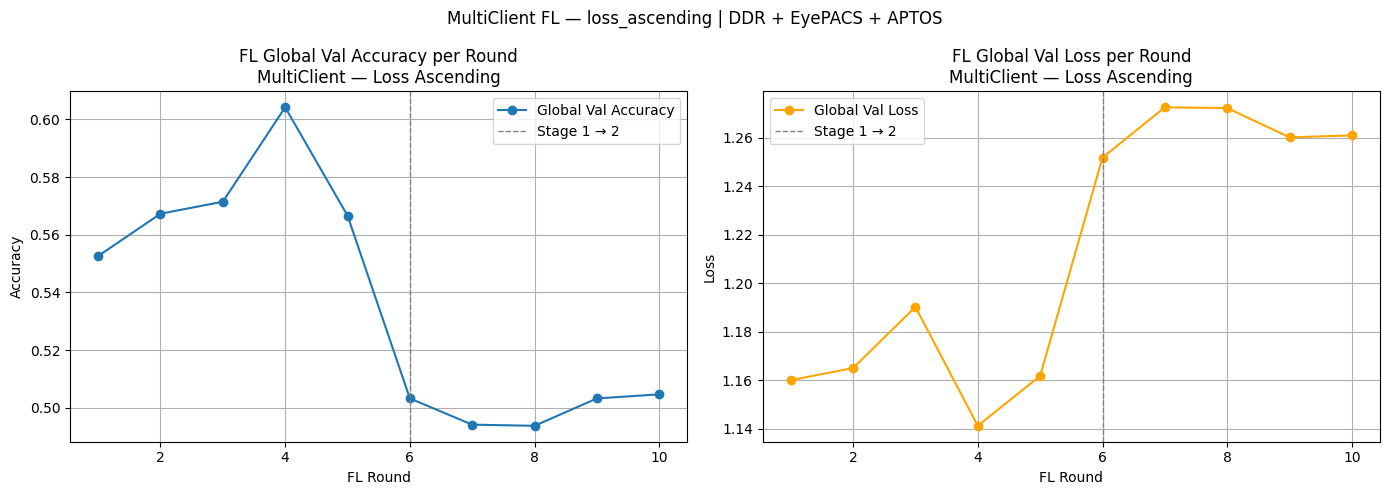

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/MultiClient/exp2_fl_loss_asc/mobilenet/figures/fl_training_curve.png


In [19]:
# =========================
# CELL 17 — PLOT FL TRAINING CURVE
# =========================
rounds_list   = [r["round"]        for r in fl_round_logs]
val_acc_list  = [r["val_accuracy"] for r in fl_round_logs]
val_loss_list = [r["val_loss"]     for r in fl_round_logs]
stage_list    = [r["stage"]        for r in fl_round_logs]

# Stage boundary
stage2_start = next((r["round"] for r in fl_round_logs if r["stage"] == 2), None)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rounds_list, val_acc_list, marker="o", label="Global Val Accuracy")
if stage2_start:
    axes[0].axvline(x=stage2_start, color="gray", linestyle="--", linewidth=1, label="Stage 1 → 2")
axes[0].set_title("FL Global Val Accuracy per Round\nMultiClient — Loss Ascending")
axes[0].set_xlabel("FL Round")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(rounds_list, val_loss_list, marker="o", color="orange", label="Global Val Loss")
if stage2_start:
    axes[1].axvline(x=stage2_start, color="gray", linestyle="--", linewidth=1, label="Stage 1 → 2")
axes[1].set_title("FL Global Val Loss per Round\nMultiClient — Loss Ascending")
axes[1].set_xlabel("FL Round")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.suptitle(f"MultiClient FL — {SORT_STRATEGY} | DDR + EyePACS + APTOS", fontsize=12)
plt.tight_layout()

fl_curve_path = os.path.join(FIGURES_DIR, "fl_training_curve.png")
plt.savefig(fl_curve_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()
print("Saved:", fl_curve_path)

In [20]:
# =========================
# CELL 18 — BUILD FINAL PREDICTION OBJECTS (GLOBAL TEST SET)
# =========================
test_probs = global_model.predict(test_ds_global, verbose=1)
test_preds = np.argmax(test_probs, axis=1)

y_true = np.array(y_test_global)
y_pred = np.array(test_preds)
y_prob = np.array(test_probs)

print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)
print("y_prob shape:", y_prob.shape)
print("Unique labels in y_true:", np.unique(y_true))

241/241 ━━━━━━━━━━━━━━━━━━━━ 25s 83ms/step
y_true shape: (7698,)
y_pred shape: (7698,)
y_prob shape: (7698, 5)
Unique labels in y_true: [0 1 2 3 4]


In [21]:
# =========================
# CELL 19 — MAIN SUMMARY TABLE
# =========================
acc = accuracy_score(y_true, y_pred)

precision_macro,    recall_macro,    f1_macro,    _ = precision_recall_fscore_support(y_true, y_pred, average="macro",    zero_division=0)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)

y_true_bin       = label_binarize(y_true, classes=np.arange(NUM_CLASSES))
auc_macro_ovr    = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="macro")
auc_weighted_ovr = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="weighted")

summary_df = pd.DataFrame([{
    "experiment_name"   : EXPERIMENT_NAME,
    "dataset_name"      : DATASET_NAME,
    "model_name"        : MODEL_NAME,
    "setup"             : f"FL {SORT_STRATEGY}",
    "evaluation_set"    : "Test (Global)",
    "accuracy"          : acc,
    "precision_macro"   : precision_macro,
    "recall_macro"      : recall_macro,
    "f1_macro"          : f1_macro,
    "precision_weighted": precision_weighted,
    "recall_weighted"   : recall_weighted,
    "f1_weighted"       : f1_weighted,
    "auc_macro_ovr"     : auc_macro_ovr,
    "auc_weighted_ovr"  : auc_weighted_ovr,
    "fl_rounds"         : FL_ROUNDS,
    "num_clients"       : NUM_CLIENTS,
    "total_train_size"  : sum(len(cy) for _, cy in client_data),
    "global_val_size"   : len(y_val_global),
    "global_test_size"  : len(y_test_global),
}])

display(summary_df)
summary_df.to_csv( os.path.join(LOGS_DIR, "baseline_summary_table.csv"),  index=False)
summary_df.to_json(os.path.join(LOGS_DIR, "baseline_summary_table.json"), orient="records", indent=4)
print("Saved: baseline_summary_table.csv / .json")

,experiment_name,dataset_name,model_name,setup,evaluation_set,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,auc_macro_ovr,auc_weighted_ovr,fl_rounds,num_clients,total_train_size,global_val_size,global_test_size
0,exp2_fl_loss_asc,MultiClient,mobilenet,FL loss_ascending,Test (Global),0.502858,0.278928,0.32391,0.274385,0.538588,0.502858,0.50528,0.68724,0.663737,10,3,35916,7696,7698


Saved: baseline_summary_table.csv / .json


In [22]:
# =========================
# CELL 20 — CLASSIFICATION REPORT (GLOBAL)
# =========================
report_text = classification_report(y_true, y_pred, digits=4)
report_dict = classification_report(y_true, y_pred, digits=4, output_dict=True)

print("Classification Report (Global Test Set):\n")
print(report_text)

with open(os.path.join(LOGS_DIR, "classification_report_test.txt"),  "w") as f: f.write(report_text)
with open(os.path.join(LOGS_DIR, "classification_report_test.json"), "w") as f: json.dump(report_dict, f, indent=4)
print("Saved: classification_report_test.txt / .json")

Classification Report (Global Test Set):

              precision    recall  f1-score   support

           0     0.7002    0.6770    0.6884      5083
           1     0.1098    0.2979    0.1605       517
           2     0.2819    0.0848    0.1304      1616
           3     0.1357    0.2359    0.1723       195
           4     0.1670    0.3240    0.2204       287

    accuracy                         0.5029      7698
   macro avg     0.2789    0.3239    0.2744      7698
weighted avg     0.5386    0.5029    0.5053      7698

Saved: classification_report_test.txt / .json


In [23]:
# =========================
# CELL 21 — PER-CLASS METRICS
# =========================
precision_cls, recall_cls, f1_cls, support_cls = precision_recall_fscore_support(
    y_true, y_pred, labels=np.arange(NUM_CLASSES), zero_division=0
)

per_class_df = pd.DataFrame({
    "class"    : np.arange(NUM_CLASSES),
    "precision": precision_cls,
    "recall"   : recall_cls,
    "f1_score" : f1_cls,
    "support"  : support_cls
})
display(per_class_df)

per_class_df.to_csv( os.path.join(LOGS_DIR, "per_class_metrics.csv"),  index=False)
per_class_df.to_json(os.path.join(LOGS_DIR, "per_class_metrics.json"), orient="records", indent=4)
print("Saved: per_class_metrics.csv / .json")

,class,precision,recall,f1_score,support
0,0,0.700244,0.676962,0.688407,5083
1,1,0.109843,0.297872,0.160500,517
2,2,0.281893,0.084777,0.130352,1616
3,3,0.135693,0.235897,0.172285,195
4,4,0.166966,0.324042,0.220379,287


Saved: per_class_metrics.csv / .json


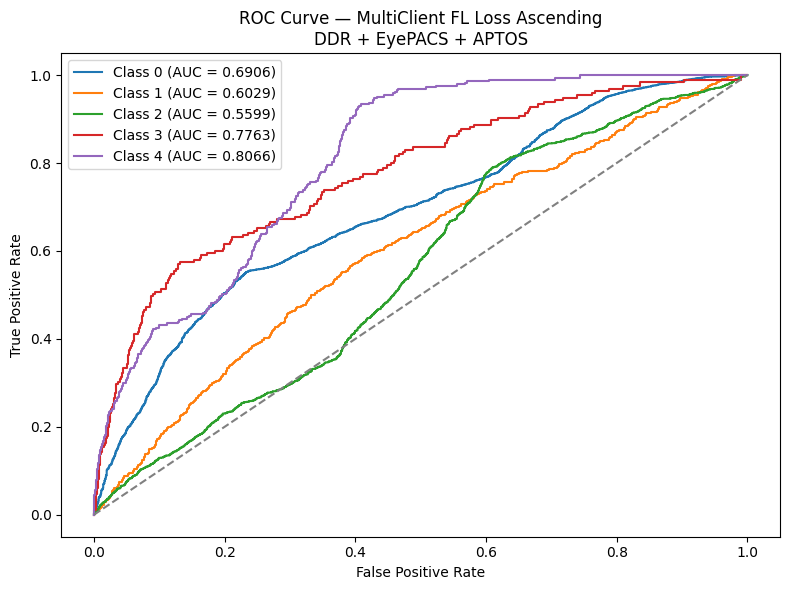

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/MultiClient/exp2_fl_loss_asc/mobilenet/figures/roc_curve_baseline.png
Saved: roc_auc_per_class.json


In [24]:
# =========================
# CELL 22 — ROC CURVE + AUC PER CLASS
# =========================
y_true_bin = label_binarize(y_true, classes=np.arange(NUM_CLASSES))

roc_auc_per_class = {}
plt.figure(figsize=(8, 6))

for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc_val = auc(fpr, tpr)
    roc_auc_per_class[f"class_{i}"] = float(roc_auc_val)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc_val:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve — MultiClient FL Loss Ascending\nDDR + EyePACS + APTOS")
plt.legend()
plt.tight_layout()

roc_path = os.path.join(FIGURES_DIR, "roc_curve_baseline.png")
plt.savefig(roc_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

with open(os.path.join(LOGS_DIR, "roc_auc_per_class.json"), "w") as f:
    json.dump(roc_auc_per_class, f, indent=4)
print("Saved:", roc_path)
print("Saved: roc_auc_per_class.json")

<Figure size 700x600 with 0 Axes>

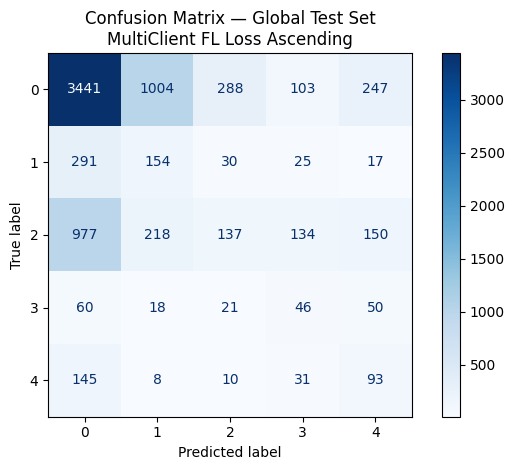

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/MultiClient/exp2_fl_loss_asc/mobilenet/figures/confusion_matrix_heatmap_baseline.png


In [25]:
# =========================
# CELL 23 — CONFUSION MATRIX HEATMAP (GLOBAL)
# =========================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(NUM_CLASSES))
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix — Global Test Set\nMultiClient FL Loss Ascending")
plt.tight_layout()

cm_path = os.path.join(FIGURES_DIR, "confusion_matrix_heatmap_baseline.png")
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

cm_df = pd.DataFrame(
    cm,
    index=[f"true_{i}"   for i in range(NUM_CLASSES)],
    columns=[f"pred_{i}" for i in range(NUM_CLASSES)]
)
cm_df.to_csv(os.path.join(LOGS_DIR, "confusion_matrix_table.csv"))
with open(os.path.join(LOGS_DIR, "confusion_matrix_values_test.json"), "w") as f:
    json.dump({"confusion_matrix": cm.tolist()}, f, indent=4)
print("Saved:", cm_path)

In [27]:
# =========================
# CELL 24 — PER-CLIENT FINAL EVALUATION
# =========================
print("Per-Client Performance on Test Set (Global Model)")
print("=" * 60)

per_client_results = []

for i, (name, (X_te, y_te)) in enumerate(zip(CLIENT_NAMES, client_test_data)):
    te_ds = make_eval_dataset(X_te, y_te)

    probs_i = global_model.predict(te_ds, verbose=0)
    preds_i = np.argmax(probs_i, axis=1)
    y_bin_i = label_binarize(y_te, classes=np.arange(NUM_CLASSES))

    c_acc          = accuracy_score(y_te, preds_i)
    c_p, c_r, c_f1, _ = precision_recall_fscore_support(y_te, preds_i, average="macro", zero_division=0)

    try:
        c_auc = roc_auc_score(y_bin_i, probs_i, multi_class="ovr", average="macro")
    except ValueError:
        c_auc = None

    auc_str = f"{c_auc:.4f}" if c_auc is not None else "N/A"

    per_client_results.append({
        "client"          : name,
        "n_test_samples"  : int(len(y_te)),
        "accuracy"        : round(c_acc, 4),
        "precision_macro" : round(c_p,   4),
        "recall_macro"    : round(c_r,   4),
        "f1_macro"        : round(c_f1,  4),
        "auc_macro_ovr"   : round(c_auc, 4) if c_auc is not None else None,
    })

    print(f"  {name:<10} | n={len(y_te):>5,} | Acc={c_acc:.4f} | F1={c_f1:.4f} | AUC={auc_str}")

print()
per_client_df = pd.DataFrame(per_client_results)
display(per_client_df)

per_client_df.to_csv( os.path.join(LOGS_DIR, "per_client_test_metrics.csv"),  index=False)
per_client_df.to_json(os.path.join(LOGS_DIR, "per_client_test_metrics.json"), orient="records", indent=4)
print("Saved: per_client_test_metrics.csv / .json")

Per-Client Performance on Test Set (Global Model)
  DDR        | n=1,879 | Acc=0.5003 | F1=0.1334 | AUC=0.4931
  EyePACS    | n=5,269 | Acc=0.5007 | F1=0.2922 | AUC=0.7286
  APTOS      | n=  550 | Acc=0.5327 | F1=0.3771 | AUC=0.7558



,client,n_test_samples,accuracy,precision_macro,recall_macro,f1_macro,auc_macro_ovr
0,DDR,1879,0.5003,0.1001,0.2000,0.1334,0.4931
1,EyePACS,5269,0.5007,0.2956,0.4132,0.2922,0.7286
2,APTOS,550,0.5327,0.4117,0.4411,0.3771,0.7558


Saved: per_client_test_metrics.csv / .json


In [28]:
# =========================
# CELL 25 — COMPARISON READY JSON
# =========================
comparison_row = {
    "method"           : f"FL_{SORT_STRATEGY}",
    "model"            : MODEL_NAME,
    "dataset"          : DATASET_NAME,
    "clients"          : CLIENT_NAMES,
    "accuracy"         : float(acc),
    "precision_macro"  : float(precision_macro),
    "recall_macro"     : float(recall_macro),
    "f1_macro"         : float(f1_macro),
    "auc_macro_ovr"    : float(auc_macro_ovr),
    "fl_rounds"        : FL_ROUNDS,
    "num_clients"      : NUM_CLIENTS,
    "total_train_size" : int(sum(len(cy) for _, cy in client_data)),
    "global_val_size"  : int(len(y_val_global)),
    "global_test_size" : int(len(y_test_global)),
    "notes"            : f"FL {SORT_STRATEGY}, {FL_ROUNDS} rounds, {NUM_CLIENTS} clients (DDR+EyePACS+APTOS). Opsi A: per-client split, global test = gabungan."
}

comparison_row_path = os.path.join(LOGS_DIR, "comparison_ready_baseline.json")
with open(comparison_row_path, "w") as f:
    json.dump(comparison_row, f, indent=4)

print("Saved:", comparison_row_path)
print(json.dumps(comparison_row, indent=4))

Saved: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/MultiClient/exp2_fl_loss_asc/mobilenet/logs/comparison_ready_baseline.json
{
    "method": "FL_loss_ascending",
    "model": "mobilenet",
    "dataset": "MultiClient",
    "clients": [
        "DDR",
        "EyePACS",
        "APTOS"
    ],
    "accuracy": 0.5028578851649779,
    "precision_macro": 0.27892787794009555,
    "recall_macro": 0.32391024793158457,
    "f1_macro": 0.27438452385878714,
    "auc_macro_ovr": 0.6872399446713126,
    "fl_rounds": 10,
    "num_clients": 3,
    "total_train_size": 35916,
    "global_val_size": 7696,
    "global_test_size": 7698,
    "notes": "FL loss_ascending, 10 rounds, 3 clients (DDR+EyePACS+APTOS). Opsi A: per-client split, global test = gabungan."
}
